# Dark Energy Scalar Field (Quintessence) Reconstruction
## Pantheon+ vs DES-Dovekie Comparison

This notebook reconstructs the dark energy equation of state as a quintessence scalar field
for three parametrizations — **ΛCDM**, **$w$CDM**, **CPL** — using two independent
Type Ia supernova datasets combined with DESI DR2 BAO and CMB priors:

| Dataset tag | SN Ia catalogue | Additional probes |
|------------|----------------|-------------------|
| **PP** | Pantheon+ (1590 cosmology SNe) | DESI DR2 BAO + CMB ($\omega_b$, $\ell_a$, $R$) |
| **DES** | DES-Dovekie (~1800 SNe, Popovic et al. 2025) | DESI DR2 BAO + CMB ($\omega_b$, $\ell_a$, $R$) |

### Why only these three models?

The constraints chapter (§ 6 of the Part A notebook) also fits $\Lambda_s$CDM,
the sign-switching cosmological constant, with the same data combination. The
profile likelihood of the transition redshift $z_\dagger$ (§ 6.3) shows a sharp
lower edge near $z_\dagger \approx 2.3$ — set by the DESI Ly$\alpha$ BAO point —
but is essentially flat from there up to the prior boundary at $z_\dagger = 3$,
with the upper boundary only $\sim 1\sigma$ disfavoured. The follow-up BAO
sensitivity study (§ 6.4) shows that alternative BAO compilations give
different and mutually inconsistent answers (the transversal BAOtr set
localises near $z_\dagger \approx 1.6$, the Akarsu BOSS+eBOSS set near
$2.25$, while DESI DR2 — our baseline, and the most precise — gives no upper
bound at all). A dark-energy reconstruction requires a single localised
best-fit point to anchor the model; for $\Lambda_s$CDM with the current data
no such robust anchor exists. We therefore
restrict this chapter to $\Lambda$CDM, $w$CDM, and CPL, whose extension
parameters are localised by the same data.

### Reconstructed quantities
For each model and dataset we compute:

1. $w(z) = w_0 + w_a\,z/(1+z)$
2. $\rho_{\mathrm{DE}}(z)/\rho_{\mathrm{DE},0}$
3. $V(z)/\rho_{\mathrm{DE},0} = \tfrac{1}{2}[1-w(z)]\,\rho_{\mathrm{DE}}/\rho_{\mathrm{DE},0}$
4. $\dot{\varphi}^2\!/2\;/\;\rho_{\mathrm{DE},0} = \tfrac{1}{2}[1+w(z)]\,\rho_{\mathrm{DE}}/\rho_{\mathrm{DE},0}$ &ensp; *(no absolute value — negative in phantom region)*
5. $\varphi(z) = \frac{\sqrt{\rho_{\mathrm{DE},0}}}{H_0}\int_0^z \frac{\sqrt{|1+w|}\;\sqrt{\rho_{\mathrm{DE}}/\rho_{\mathrm{DE},0}}}{(1+z')\,E(z')}\,dz'$
6. $V(\varphi)$: parametric plot of $V$ vs $\varphi$

### Uncertainty bands
Weighted 16th / 50th / 84th percentiles via **cumulative-weight interpolation**
on Nautilus posterior samples.

### Phantom crossing convention
- $\dot{\varphi}^2/2$ is shown **without** $|\cdot|$ so that the phantom region ($w<-1$) appears as negative kinetic energy.
- $\varphi(z)$ uses $\sqrt{|1+w|}$ to avoid NaN; a vertical dashed line marks where $w=-1$.
- In the $V(\varphi)$ parametric plot for CPL, the quintessence ($w>-1$) and phantom ($w<-1$) branches are shown with different line styles.


In [1]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Cosmological Functions

In [2]:
c = 299792.458
Tcmb = 2.7255
cH0 = 2997.92458

def E2(z, om, h, w0, wa):
    z = np.asarray(z, dtype=float)
    a = 1.0 / (1.0 + z)
    om_r = 4.18e-5 / h**2
    om_de = 1.0 - om - om_r
    rde = a**(-3.0*(1.0 + w0 + wa)) * np.exp(-3.0*wa*(1.0 - a))
    return om * a**(-3) + om_r * a**(-4) + om_de * rde

def E(z, om, h, w0, wa):
    return np.sqrt(np.clip(E2(z, om, h, w0, wa), 1e-30, None))

def H_z(z, om, h, w0, wa):
    return 100.0 * h * E(z, om, h, w0, wa)

## 2. Weighted Percentile (Cumulative-Weight Interpolation)

In [3]:
def weighted_percentile(values, weights, percentiles):

    values = np.asarray(values)
    weights = np.asarray(weights, dtype=float)
    percentiles = np.asarray(percentiles) / 100.0

    if values.ndim == 1:
        values = values[:, None]
        squeeze = True
    else:
        squeeze = False

    n_samples, n_z = values.shape
    result = np.zeros((len(percentiles), n_z))

    for j in range(n_z):
        col = values[:, j]
        sort_idx = np.argsort(col)
        sorted_vals = col[sort_idx]
        sorted_w = weights[sort_idx]

        cumw = np.cumsum(sorted_w)
        cumw /= cumw[-1]
        cumw_mid = cumw - 0.5 * sorted_w / sorted_w.sum()

        for ip, p in enumerate(percentiles):
            result[ip, j] = np.interp(p, cumw_mid, sorted_vals)

    if squeeze:
        result = result[:, 0]
    return result

## 3. Single-Sample Reconstruction

For one set of parameters $(\Omega_m, h, w_0, w_a)$, compute all quintessence quantities.

In [4]:
def reconstruct_single(z_arr, om, h, w0, wa):
    z = z_arr
    a = 1.0 / (1.0 + z)

    # w(z)
    wz = w0 + wa * z / (1.0 + z)

    # rho_DE(z) / rho_DE,0
    rho_ratio = (1.0 + z)**(3.0*(1.0 + w0 + wa)) * np.exp(-3.0*wa*z/(1.0 + z))

    # V(z) / rho_DE,0
    V_ratio = 0.5 * (1.0 - wz) * rho_ratio

    # phidot^2/2 / rho_DE,0  (NO absolute value)
    phidot2_half = 0.5 * (1.0 + wz) * rho_ratio

    # phi(z) with sqrt|1+w|
    Ez = E(z, om, h, w0, wa)
    integrand = np.sqrt(np.abs(1.0 + wz)) * np.sqrt(np.clip(rho_ratio, 0, None)) \
                / ((1.0 + z) * Ez)
    phi_cum = np.zeros_like(z)
    phi_cum[1:] = cumulative_trapezoid(integrand, z)

    # Phantom crossing redshift
    z_phantom = None
    if np.abs(wa) > 1e-10:
        x_ph = (-1.0 - w0) / wa
        if 0 < x_ph < 1:
            z_phantom = x_ph / (1.0 - x_ph)
            if z_phantom > z[-1] or z_phantom < z[0]:
                z_phantom = None

    return {
        'w': wz, 'rho_ratio': rho_ratio, 'V_ratio': V_ratio,
        'phidot2_half': phidot2_half, 'phi': phi_cum, 'z_phantom': z_phantom,
    }

## 4. Compute Uncertainty Bands from Posterior Samples

In [5]:
def compute_bands(z_arr, pts, lw, w0_col=None, wa_col=None,
                  w0_fixed=None, wa_fixed=None, n_thin=2000):
    weights = np.exp(lw - lw.max())
    weights /= weights.sum()
    n_samples = len(weights)

    if n_samples > n_thin:
        # Stratified random sampling preserving original weights
        rng = np.random.default_rng(42)
        indices = rng.choice(n_samples, size=n_thin, replace=False, p=weights)
        pts_use = pts[indices]
        weights_use = weights[indices]
        weights_use /= weights_use.sum()
    else:
        pts_use = pts
        weights_use = weights

    n_use = len(weights_use)
    n_z = len(z_arr)

    keys = ['w', 'rho_ratio', 'V_ratio', 'phidot2_half', 'phi']
    all_vals = {k: np.zeros((n_use, n_z)) for k in keys}
    z_phantoms = []

    for i in range(n_use):
        om_i = float(pts_use[i, 0])
        h_i  = float(pts_use[i, 1])
        w0_i = w0_fixed if w0_fixed is not None else float(pts_use[i, w0_col])
        wa_i = wa_fixed if wa_fixed is not None else float(pts_use[i, wa_col])

        rec = reconstruct_single(z_arr, om_i, h_i, w0_i, wa_i)
        for k in keys:
            all_vals[k][i, :] = rec[k]
        if rec['z_phantom'] is not None:
            z_phantoms.append(rec['z_phantom'])

    bands = {}
    for k in keys:
        lo, med, hi = weighted_percentile(all_vals[k], weights_use, [16, 50, 84])
        bands[k] = (lo, med, hi)

    z_phantom_med = np.median(z_phantoms) if len(z_phantoms) > len(weights_use)*0.3 else None
    return bands, z_phantom_med

## 5. Load Posterior Samples

Chain file column layout:

| Model | PP columns | DES columns |
|-------|-----------|-------------|
| ΛCDM  | `[Ωm, h, ωb, Mcal]` | `[Ωm, h, ωb]` |
| $w$CDM | `[Ωm, h, ωb, w₀, Mcal]` | `[Ωm, h, ωb, w₀]` |
| CPL   | `[Ωm, h, ωb, w₀, wₐ, Mcal]` | `[Ωm, h, ωb, w₀, wₐ]` |

DES chains do not include $\mathcal{M}$ (absolute SN magnitude) — this does not affect
the reconstruction since $\mathcal{M}$ is a nuisance parameter.

In [15]:
# Pantheon+ combined (PP + DESI DR2 + CMB)
pts_lcdm_pp = np.load('chains_LCDM_combined_PP_pts.npy')
lw_lcdm_pp  = np.load('chains_LCDM_combined_PP_logw.npy')
pts_wcdm_pp = np.load('chains_wCDM_combined_PP_pts.npy')
lw_wcdm_pp  = np.load('chains_wCDM_combined_PP_logw.npy')
pts_cpl_pp  = np.load('chains_CPL_combined_PP_pts.npy')
lw_cpl_pp   = np.load('chains_CPL_combined_PP_logw.npy')

# DES-Dovekie combined (DES + DESI DR2 + CMB)
pts_lcdm_des = np.load('chains_LCDM_combined_DES_pts.npy')
lw_lcdm_des  = np.load('chains_LCDM_combined_DES_logw.npy')
pts_wcdm_des = np.load('chains_wCDM_combined_DES_pts.npy')
lw_wcdm_des  = np.load('chains_wCDM_combined_DES_logw.npy')
pts_cpl_des  = np.load('chains_CPL_combined_DES_pts.npy')
lw_cpl_des   = np.load('chains_CPL_combined_DES_logw.npy')

print("Pantheon+ combined chains:")
print(f"  LCDM : {pts_lcdm_pp.shape[0]:,} samples, {pts_lcdm_pp.shape[1]} params")
print(f"  wCDM : {pts_wcdm_pp.shape[0]:,} samples, {pts_wcdm_pp.shape[1]} params")
print(f"  CPL  : {pts_cpl_pp.shape[0]:,} samples, {pts_cpl_pp.shape[1]} params")
print()
print("DES-Dovekie combined chains:")
print(f"  LCDM : {pts_lcdm_des.shape[0]:,} samples, {pts_lcdm_des.shape[1]} params")
print(f"  wCDM : {pts_wcdm_des.shape[0]:,} samples, {pts_wcdm_des.shape[1]} params")
print(f"  CPL  : {pts_cpl_des.shape[0]:,} samples, {pts_cpl_des.shape[1]} params")

Pantheon+ combined chains:
  LCDM : 49,400 samples, 4 params
  wCDM : 59,200 samples, 5 params
  CPL  : 66,300 samples, 6 params

DES-Dovekie combined chains:
  LCDM : 38,500 samples, 3 params
  wCDM : 47,300 samples, 4 params
  CPL  : 54,700 samples, 5 params


## 6. Compute Reconstruction Bands

In [7]:
z_arr = np.linspace(1e-4, 2.5, 500)
np.random.seed(42)

print("=" * 50)
print("Pantheon+ + DESI DR2 + CMB")
print("=" * 50)
print("  LCDM...", end=" ")
bands_lcdm_pp, zph_lcdm_pp = compute_bands(
    z_arr, pts_lcdm_pp, lw_lcdm_pp,
    w0_fixed=-1.0, wa_fixed=0.0)
print("done")
print("  wCDM...", end=" ")
bands_wcdm_pp, zph_wcdm_pp = compute_bands(
    z_arr, pts_wcdm_pp, lw_wcdm_pp,
    w0_col=3, wa_fixed=0.0)
print("done")
print("  CPL ...", end=" ")
bands_cpl_pp, zph_cpl_pp = compute_bands(
    z_arr, pts_cpl_pp, lw_cpl_pp,
    w0_col=3, wa_col=4)
print("done")
if zph_cpl_pp:
    print(f"  -> CPL phantom crossing at z = {zph_cpl_pp:.3f}")

print()
print("=" * 50)
print("DES-Dovekie + DESI DR2 + CMB")
print("=" * 50)
print("  LCDM...", end=" ")
bands_lcdm_des, zph_lcdm_des = compute_bands(
    z_arr, pts_lcdm_des, lw_lcdm_des,
    w0_fixed=-1.0, wa_fixed=0.0)
print("done")
print("  wCDM...", end=" ")
bands_wcdm_des, zph_wcdm_des = compute_bands(
    z_arr, pts_wcdm_des, lw_wcdm_des,
    w0_col=3, wa_fixed=0.0)
print("done")
print("  CPL ...", end=" ")
bands_cpl_des, zph_cpl_des = compute_bands(
    z_arr, pts_cpl_des, lw_cpl_des,
    w0_col=3, wa_col=4)
print("done")
if zph_cpl_des:
    print(f"  -> CPL phantom crossing at z = {zph_cpl_des:.3f}")

bands_pp = {
    'LCDM': (bands_lcdm_pp, zph_lcdm_pp),
    'wCDM': (bands_wcdm_pp, zph_wcdm_pp),
    'CPL':  (bands_cpl_pp,  zph_cpl_pp),
}
bands_des = {
    'LCDM': (bands_lcdm_des, zph_lcdm_des),
    'wCDM': (bands_wcdm_des, zph_wcdm_des),
    'CPL':  (bands_cpl_des,  zph_cpl_des),
}

Pantheon+ + DESI DR2 + CMB
  LCDM... done
  wCDM... done
  CPL ... done
  -> CPL phantom crossing at z = 0.389

DES-Dovekie + DESI DR2 + CMB
  LCDM... done
  wCDM... done
  CPL ... done
  -> CPL phantom crossing at z = 0.380


## 7. Plot Configuration

In [8]:
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 13,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

COLORS = {'LCDM': '#2c3e50', 'wCDM': '#c0392b', 'CPL': '#2980b9'}
LABELS = {'LCDM': r'$\Lambda$CDM', 'wCDM': r'$w$CDM', 'CPL': r'CPL'}

def plot_panel(ax, z_arr, bands_dict, quantity, ylabel,
               show_phantom=True, title=None,
               models=('LCDM', 'wCDM', 'CPL')):
    z_ph_global = None
    for model in models:
        if model not in bands_dict:
            continue
        bands, z_ph = bands_dict[model]
        lo, med, hi = bands[quantity]
        col = COLORS[model]
        lab = LABELS[model]
        ax.plot(z_arr, med, color=col, label=lab, zorder=3)
        ax.fill_between(z_arr, lo, hi, color=col, alpha=0.18, zorder=1)
        if z_ph is not None:
            z_ph_global = z_ph

    ax.set_xlim(z_arr[0], z_arr[-1])

    if show_phantom and z_ph_global is not None:
        ax.axvline(z_ph_global, color='grey', ls='--', lw=1.0, alpha=0.7, zorder=2)
        yl = ax.get_ylim()
        ax.text(z_ph_global + 0.03, yl[0] + 0.05*(yl[1]-yl[0]),
                r'$w\!=\!-1$', fontsize=9, color='grey', va='bottom')

    ax.set_xlabel(r'$z$')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')

### Plot 1: Equation of State $w(z)$

**What this shows:** The dark energy equation of state $w(z) = p_{\rm DE}/\rho_{\rm DE}$.

**Legend:**
- **Dark line (ΛCDM):** $w = -1$ exactly — the cosmological constant. Narrow band from $\Omega_m$, $h$ variation.
- **Red line ($w$CDM):** Constant $w_0$ fit freely. Median $\approx -0.98$, consistent with $\Lambda$ at $1\sigma$.
- **Blue line (CPL):** $w(z) = w_0 + w_a z/(1+z)$. Shows $w > -1$ at low $z$, evolving to $w < -1$ at high $z$.
- **Shaded bands:** 68% credible intervals (16th–84th percentile).
- **Grey dashed line:** Phantom divide crossing redshift for CPL.
- **Dotted horizontal:** $w = -1$ reference.

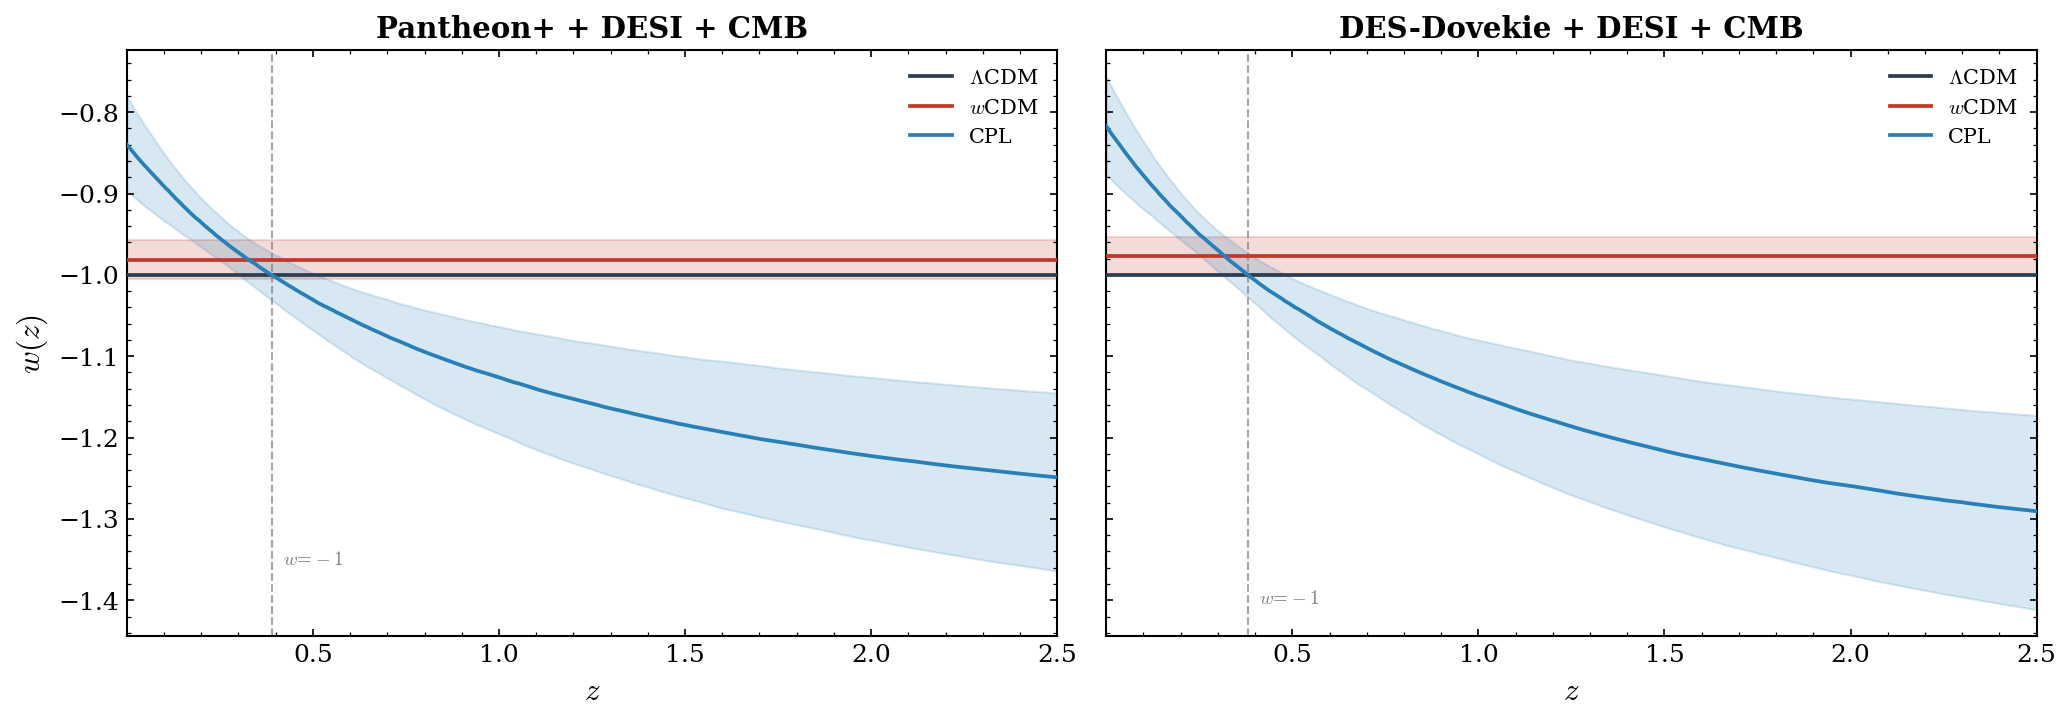

In [9]:
fig, (ax_pp, ax_des) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_panel(ax_pp, z_arr, bands_pp, 'w', r'$w(z)$', title='Pantheon+ + DESI + CMB')
plot_panel(ax_des, z_arr, bands_des, 'w', r'$w(z)$', title='DES-Dovekie + DESI + CMB')
ax_des.set_ylabel('')

for ax in [ax_pp, ax_des]:
    ax.axhline(-1, color='black', ls=':', lw=0.8, alpha=0.5)
    ax.legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig('de_recon_1_wz.pdf')
fig.savefig('de_recon_1_wz.png')
plt.show()

### Plot 2: Dark Energy Density $\rho_{\rm DE}(z)/\rho_{\rm DE,0}$

**What this shows:** Ratio of DE density at redshift $z$ to its present-day value.

**Legend:**
- **ΛCDM (dark):** Flat at 1 — cosmological constant has constant density.
- **$w$CDM (red):** Slowly increasing with $z$ since $w_0 \gtrsim -1$.
- **CPL (blue):** Non-monotonic behaviour possible; band widens at high $z$ from $w_a$ uncertainty.
- **Shaded bands:** 68% credible intervals.

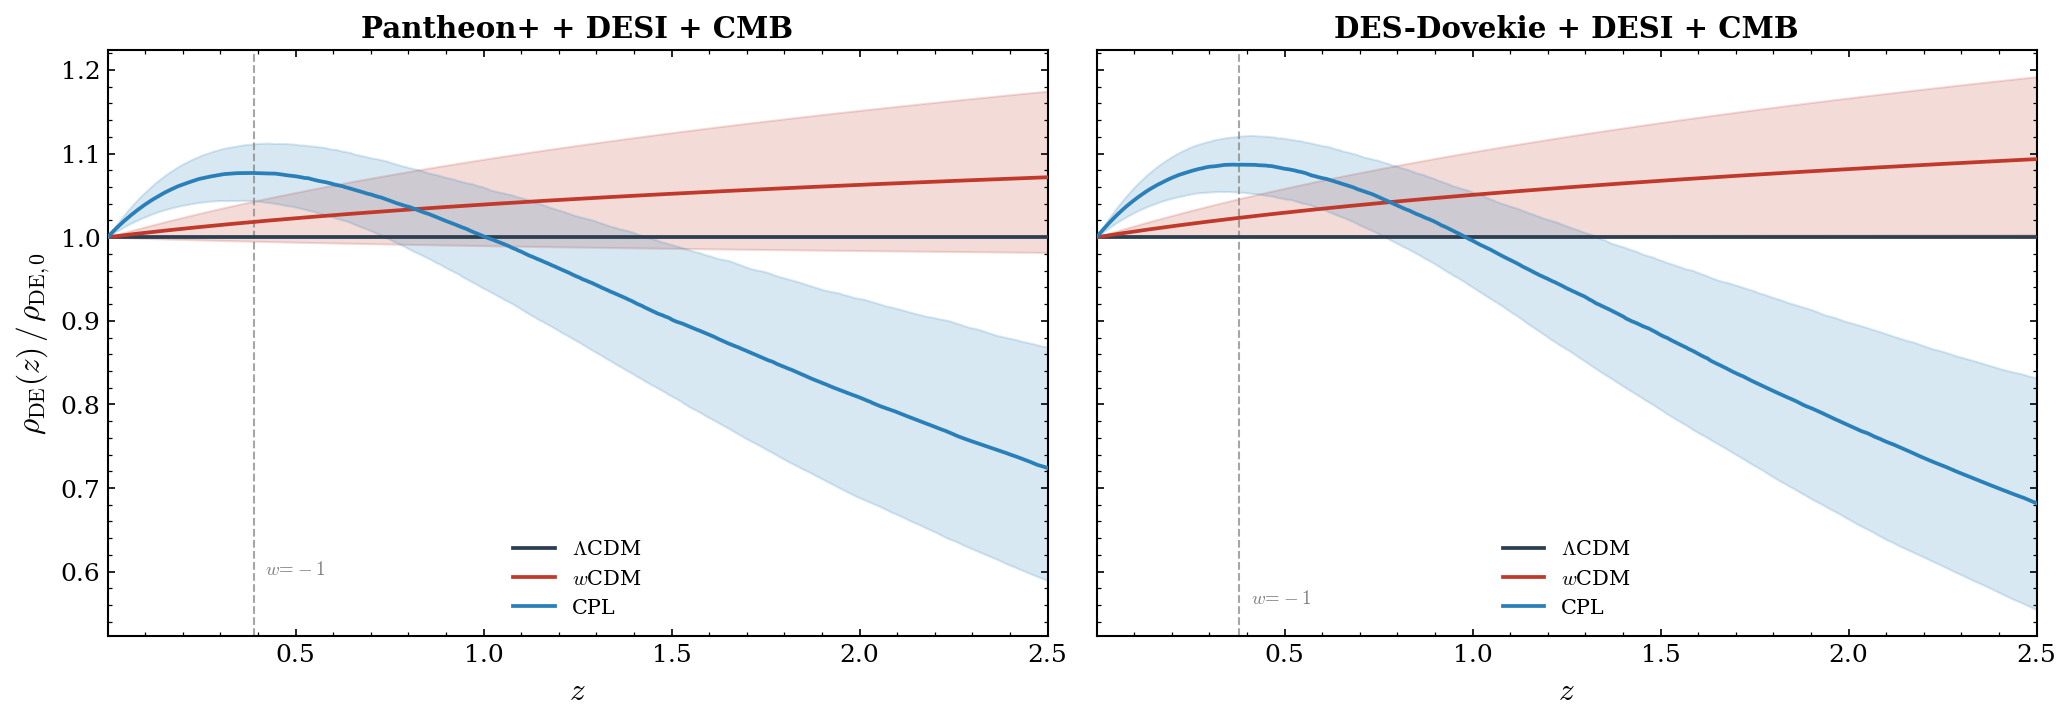

In [10]:
fig, (ax_pp, ax_des) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_panel(ax_pp, z_arr, bands_pp, 'rho_ratio',
           r'$\rho_{\rm DE}(z)\,/\,\rho_{\rm DE,0}$', title='Pantheon+ + DESI + CMB')
plot_panel(ax_des, z_arr, bands_des, 'rho_ratio',
           r'$\rho_{\rm DE}(z)\,/\,\rho_{\rm DE,0}$', title='DES-Dovekie + DESI + CMB')
ax_des.set_ylabel('')

for ax in [ax_pp, ax_des]:
    ax.legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig('de_recon_2_rho.pdf')
fig.savefig('de_recon_2_rho.png')
plt.show()

### Plot 3: Scalar Field Potential $V(z)/\rho_{\rm DE,0}$

**What this shows:** Quintessence potential energy $V = \tfrac{1}{2}(1-w)\rho_{\rm DE}$.

**Legend:**
- **ΛCDM (dark):** $w=-1 \Rightarrow V = \rho_{\rm DE} = $ const — all energy is potential.
- **$w$CDM (red):** $V < \rho_{\rm DE}$ because some energy is kinetic ($w > -1$).
- **CPL (blue):** In phantom region ($w<-1$), $V > \rho_{\rm DE}$ since $(1-w)>2$.
- **Shaded bands:** 68% credible intervals.

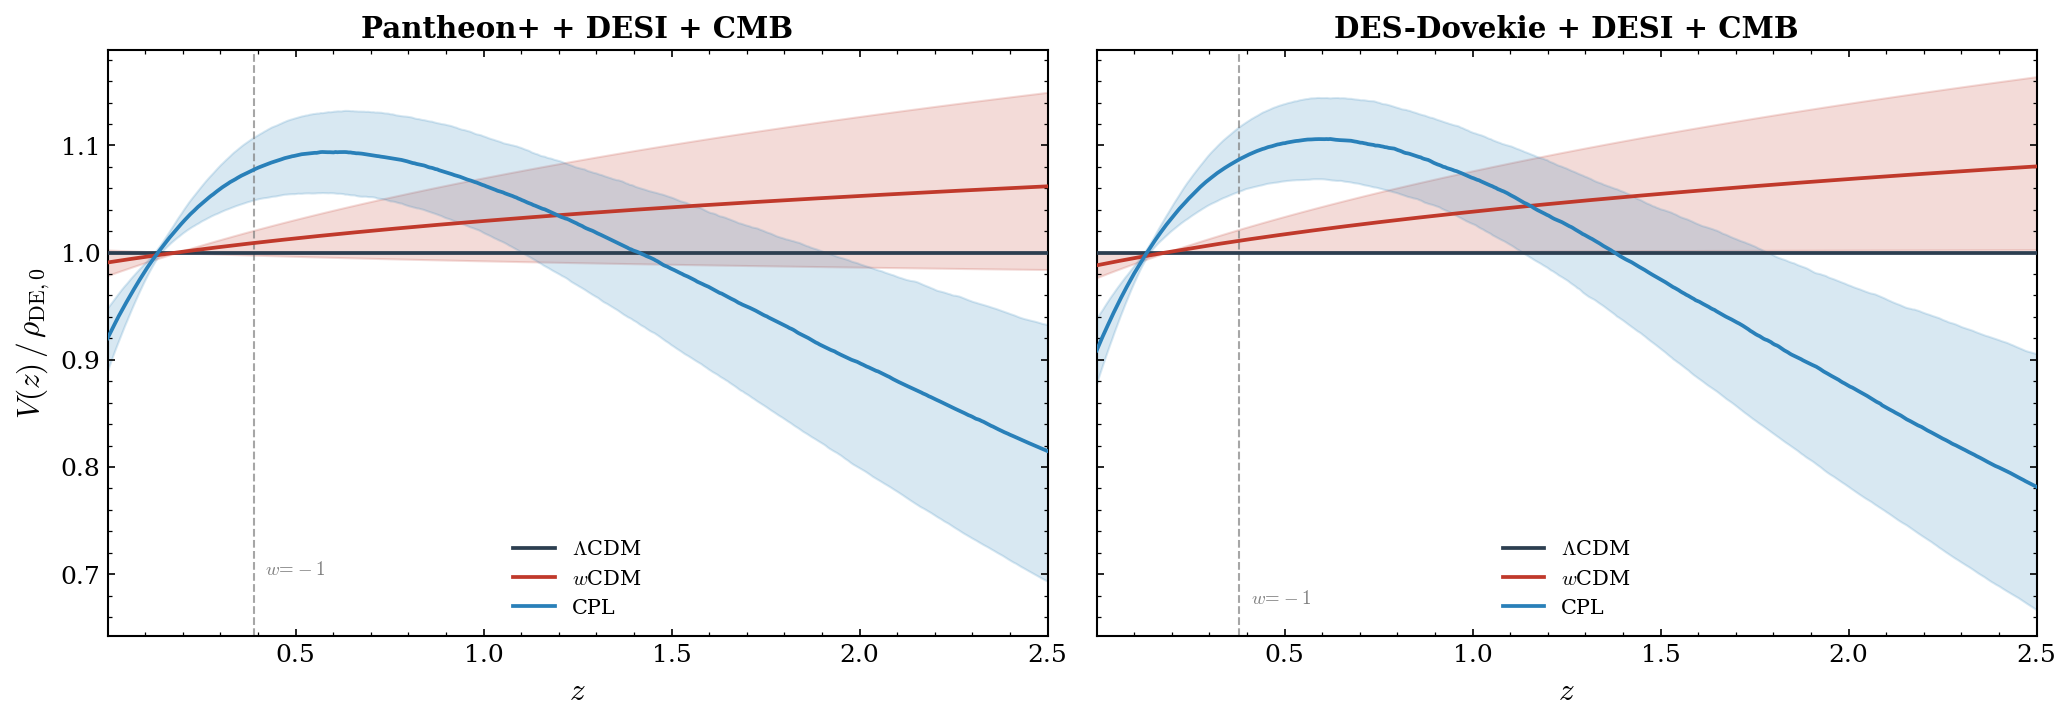

In [11]:
fig, (ax_pp, ax_des) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_panel(ax_pp, z_arr, bands_pp, 'V_ratio',
           r'$V(z)\,/\,\rho_{\rm DE,0}$', title='Pantheon+ + DESI + CMB')
plot_panel(ax_des, z_arr, bands_des, 'V_ratio',
           r'$V(z)\,/\,\rho_{\rm DE,0}$', title='DES-Dovekie + DESI + CMB')
ax_des.set_ylabel('')

for ax in [ax_pp, ax_des]:
    ax.legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig('de_recon_3_Vz.pdf')
fig.savefig('de_recon_3_Vz.png')
plt.show()

### Plot 4: Kinetic Energy $\dot{\varphi}^2/2$ (no absolute value)

**What this shows:** $\dot{\varphi}^2/2 = \tfrac{1}{2}(1+w)\rho_{\rm DE}$, with its physical sign.

**⚠️ No absolute value** — phantom region appears as negative kinetic energy.

**Legend:**
- **ΛCDM (dark):** Identically zero — no kinetic energy.
- **$w$CDM (red):** Small positive value, consistent with slowly rolling field.
- **CPL (blue):** Positive at low $z$ (quintessence, $w>-1$), crosses zero at phantom divide, becomes **negative** at higher $z$ ($w<-1$). Negative kinetic energy signals that a canonical scalar field is insufficient — phantom or quintom model required.
- **Dotted horizontal:** $\dot{\varphi}^2/2 = 0$ reference.
- **Grey dashed:** Phantom crossing redshift.

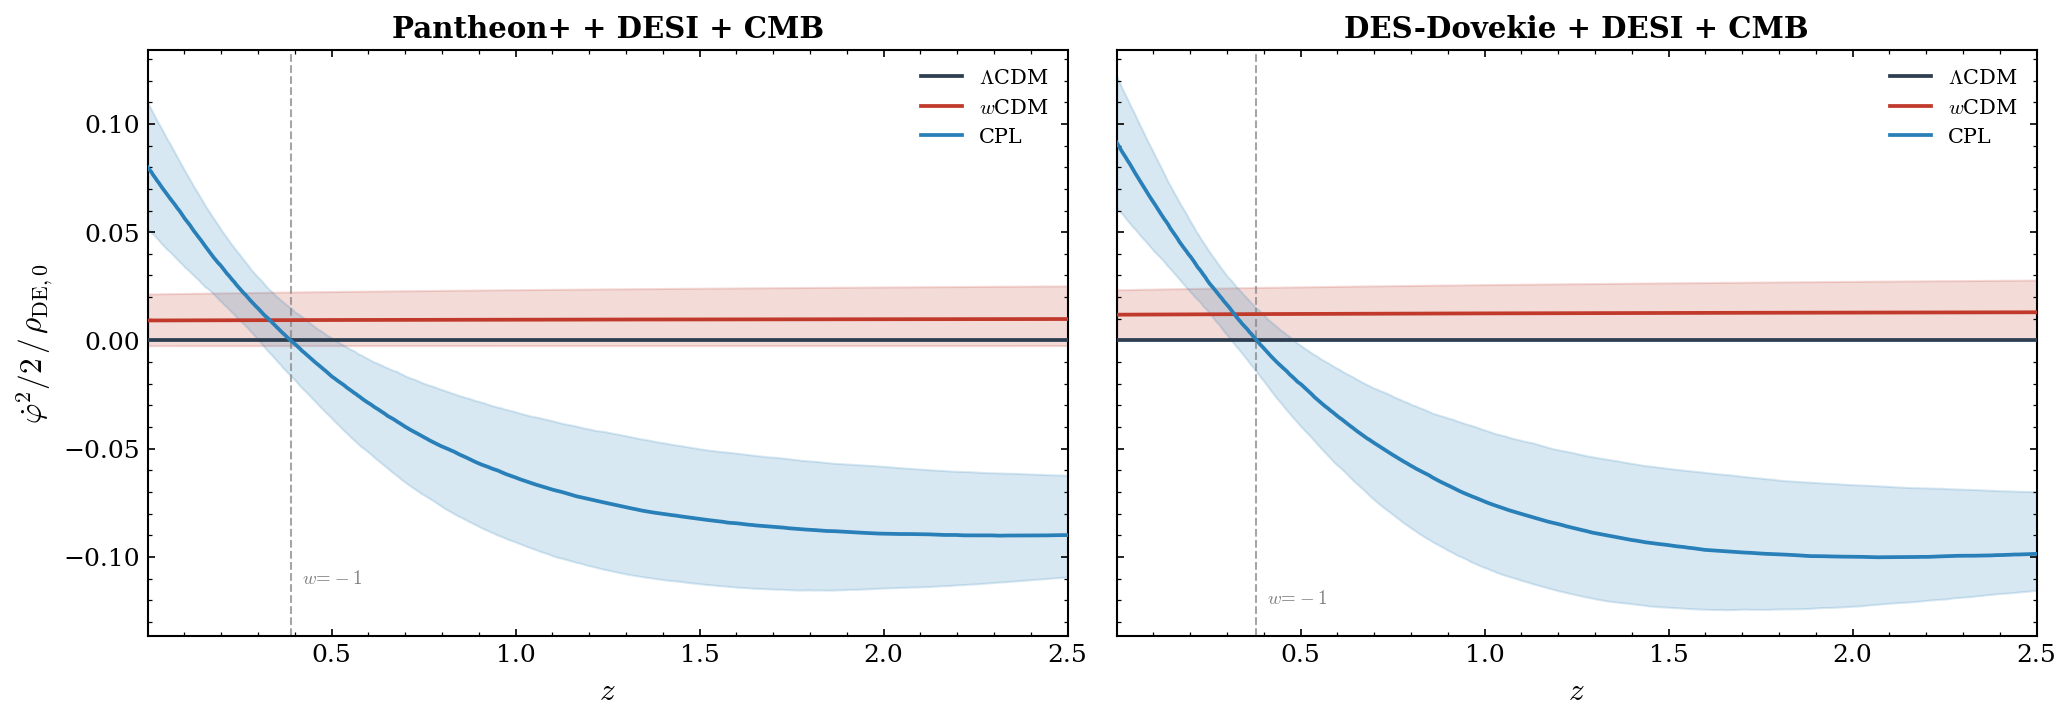

In [12]:
fig, (ax_pp, ax_des) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_panel(ax_pp, z_arr, bands_pp, 'phidot2_half',
           r'$\dot{\varphi}^2/2\,/\,\rho_{\rm DE,0}$', title='Pantheon+ + DESI + CMB')
plot_panel(ax_des, z_arr, bands_des, 'phidot2_half',
           r'$\dot{\varphi}^2/2\,/\,\rho_{\rm DE,0}$', title='DES-Dovekie + DESI + CMB')
ax_des.set_ylabel('')

for ax in [ax_pp, ax_des]:
    ax.axhline(0, color='black', ls=':', lw=0.8, alpha=0.5)
    ax.legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig('de_recon_4_phidot2.pdf')
fig.savefig('de_recon_4_phidot2.png')
plt.show()

### Plot 5: Scalar Field Evolution $\varphi(z)$

**What this shows:** Field displacement $\varphi(z) = \int_0^z (\ldots)\,dz'$ in units of $\sqrt{\rho_{\rm DE,0}}/H_0$.

**Legend:**
- **ΛCDM (dark):** $\varphi = 0$ — no dynamical field.
- **$w$CDM (red):** Monotonically increasing — field rolls along potential.
- **CPL (blue):** Increasing with subtle slope change near phantom crossing. Uses $\sqrt{|1+w|}$ to remain real.
- **Shaded bands:** 68% credible intervals. CPL band wider due to $w_a$ freedom.

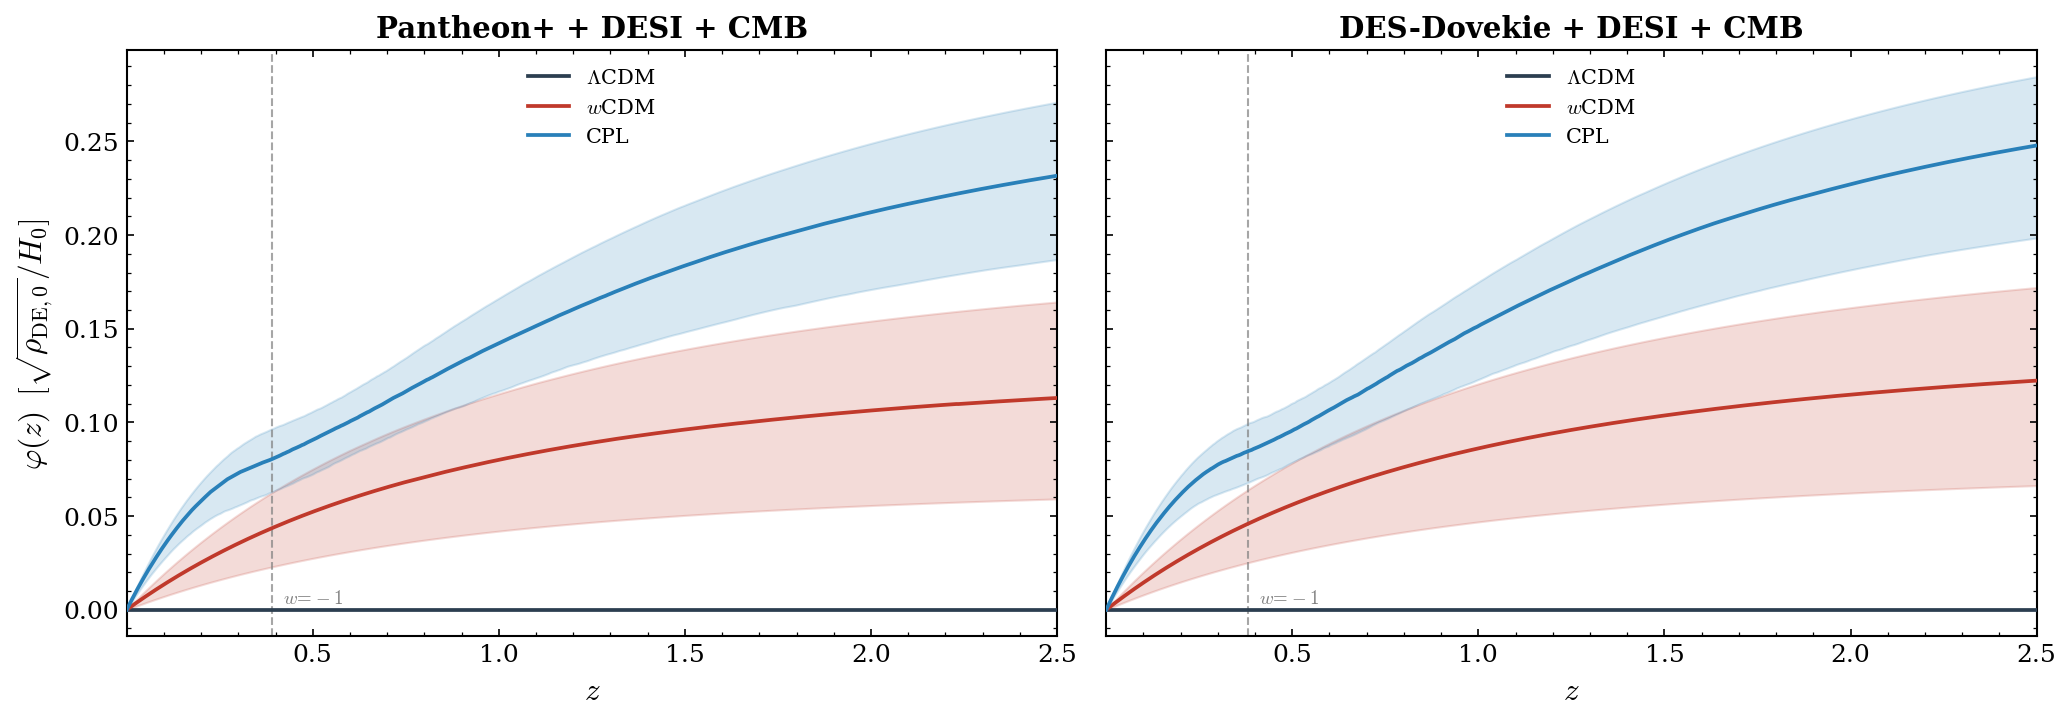

In [13]:
fig, (ax_pp, ax_des) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_panel(ax_pp, z_arr, bands_pp, 'phi',
           r'$\varphi(z)\;\;[\sqrt{\rho_{\rm DE,0}}/H_0]$', title='Pantheon+ + DESI + CMB')
plot_panel(ax_des, z_arr, bands_des, 'phi',
           r'$\varphi(z)\;\;[\sqrt{\rho_{\rm DE,0}}/H_0]$', title='DES-Dovekie + DESI + CMB')
ax_des.set_ylabel('')

for ax in [ax_pp, ax_des]:
    ax.legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig('de_recon_5_phi.pdf')
fig.savefig('de_recon_5_phi.png')
plt.show()

### Plot 6: Reconstructed Potential $V(\varphi)$ — Parametric

**What this shows:** The quintessence potential as a function of the field value, constructed parametrically from $V(z)$ and $\varphi(z)$. This is the central result — it shows what shape the potential must have to produce the observed expansion history.

**Legend:**
- **$w$CDM:** Gently sloping potential — slowly rolling field.
- **CPL solid (quintessence, $w > -1$):** Canonical scalar field region.
- **CPL dashed (phantom, $w < -1$):** Beyond phantom divide — requires phantom field or quintom scenario. Hatched uncertainty band.
- **Grey dot:** Phantom crossing point $w = -1$.

ΛCDM omitted: $\varphi = 0$, $V = \text{const}$ (single point).

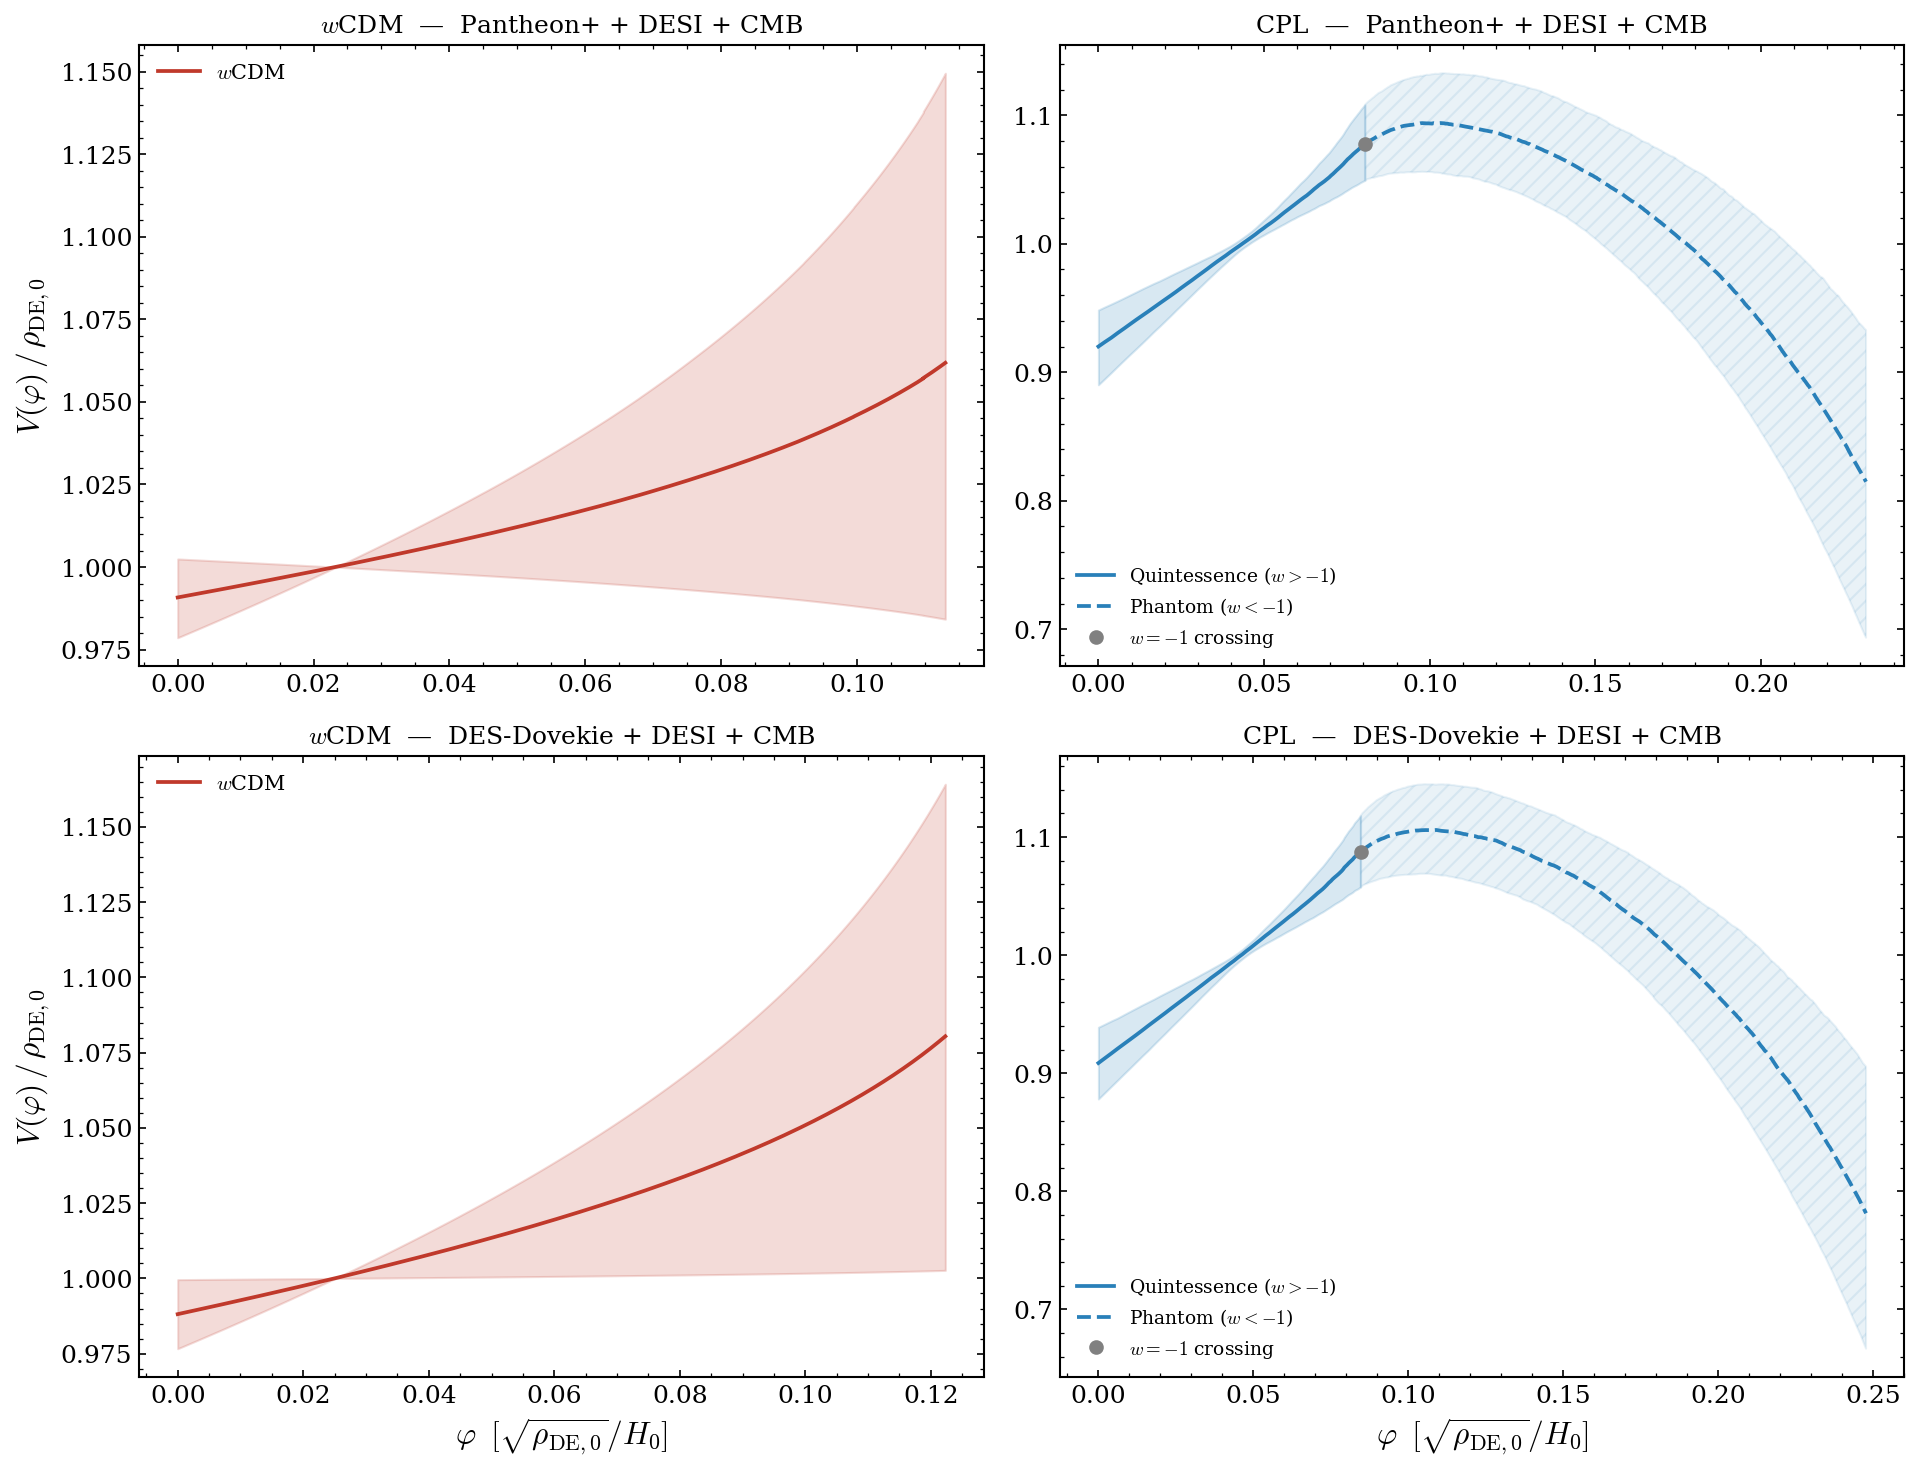

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (tag, all_b, dataset_label) in enumerate([
    ('PP',  bands_pp,  'Pantheon+ + DESI + CMB'),
    ('DES', bands_des, 'DES-Dovekie + DESI + CMB'),
]):
    # wCDM panel
    ax_w = axes[row, 0]
    b_w, _ = all_b['wCDM']
    phi_w = b_w['phi'][1]
    V_w   = b_w['V_ratio']
    ax_w.plot(phi_w, V_w[1], color=COLORS['wCDM'], label=LABELS['wCDM'])
    ax_w.fill_between(phi_w, V_w[0], V_w[2], color=COLORS['wCDM'], alpha=0.18)
    ax_w.set_ylabel(r'$V(\varphi)\,/\,\rho_{\rm DE,0}$')
    ax_w.set_title(f'{LABELS["wCDM"]}  \u2014  {dataset_label}', fontsize=12)
    ax_w.legend(frameon=False)

    # CPL panel
    ax_c = axes[row, 1]
    b_c, z_ph = all_b['CPL']
    phi_c = b_c['phi'][1]
    V_c   = b_c['V_ratio']

    if z_ph is not None:
        idx_ph = np.argmin(np.abs(z_arr - z_ph))
        sl1 = slice(0, idx_ph + 1)
        sl2 = slice(idx_ph, None)

        ax_c.plot(phi_c[sl1], V_c[1][sl1], color=COLORS['CPL'],
                  ls='-', label=r'Quintessence ($w > -1$)')
        ax_c.fill_between(phi_c[sl1], V_c[0][sl1], V_c[2][sl1],
                          color=COLORS['CPL'], alpha=0.18)

        ax_c.plot(phi_c[sl2], V_c[1][sl2], color=COLORS['CPL'],
                  ls='--', label=r'Phantom ($w < -1$)')
        ax_c.fill_between(phi_c[sl2], V_c[0][sl2], V_c[2][sl2],
                          color=COLORS['CPL'], alpha=0.10, hatch='///')

        ax_c.plot(phi_c[idx_ph], V_c[1][idx_ph], 'o',
                  color='grey', ms=6, zorder=5, label=r'$w=-1$ crossing')
    else:
        ax_c.plot(phi_c, V_c[1], color=COLORS['CPL'], label=LABELS['CPL'])
        ax_c.fill_between(phi_c, V_c[0], V_c[2], color=COLORS['CPL'], alpha=0.18)

    ax_c.set_title(f'{LABELS["CPL"]}  \u2014  {dataset_label}', fontsize=12)
    ax_c.legend(frameon=False, fontsize=9)

for ax in axes[1, :]:
    ax.set_xlabel(r'$\varphi\;\;[\sqrt{\rho_{\rm DE,0}}/H_0]$')
for ax in axes[:, 1]:
    ax.set_ylabel('')

fig.tight_layout()
fig.savefig('de_recon_6_Vphi.pdf')
fig.savefig('de_recon_6_Vphi.png')
plt.show()

---
## Summary

### Best-fit parameters (weighted median)

| Parameter | ΛCDM PP | ΛCDM DES | $w$CDM PP | $w$CDM DES | CPL PP | CPL DES |
|-----------|---------|----------|-----------|------------|--------|--------|
| $\Omega_m$ | 0.3227 | 0.3225 | 0.3257 | 0.3249 | 0.3250 | 0.3244 |
| $h$ | 0.6706 | 0.6707 | 0.6668 | 0.6677 | 0.6685 | 0.6697 |
| $w_0$ | $-1$ (fixed) | $-1$ (fixed) | $-0.983$ | $-0.986$ | $-0.935$ | $-0.909$ |
| $w_a$ | $0$ (fixed) | $0$ (fixed) | $0$ (fixed) | $0$ (fixed) | $-0.225$ | $-0.361$ |

### Key observations

1. **ΛCDM** serves as the baseline: $w = -1$ exactly, $\varphi = 0$, $V = \text{const}$.

2. **$w$CDM** is very close to ΛCDM in both datasets ($w_0 \approx -0.98$), indicating minimal departure from the cosmological constant.

3. **CPL** shows a phantom crossing at $z \approx 0.3$ in both datasets. DES shows a slightly stronger preference for phantom crossing ($w_a \approx -0.36$ vs $-0.23$ for PP).

4. The **negative kinetic energy** in the phantom region of CPL indicates that a single canonical quintessence field is insufficient — a phantom or quintom model would be required.

5. Both datasets give **consistent results** within uncertainties, strengthening the robustness of the reconstruction.